# Task 2.1 — Dataset Selection and Preprocessing

**Paper:** *Analysis of SVM with Indefinite Kernels* (NIPS 2009)

---

This notebook loads, preprocesses, and visualizes the dataset used for reproducing the paper's experiments.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

# Plot aesthetics
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Dataset Selection

We use the **Iris dataset** for our experiments:

### Why Iris?
- **Well-understood:** Classic ML benchmark with known properties
- **Sufficient samples:** 150 samples (100 for binary subset) — exceeds minimum of 100
- **Multiple features:** 4 features — exceeds minimum of 2
- **Non-linearly separable classes:** Classes 1 (Versicolour) and 2 (Virginica) are not linearly separable, making them ideal for kernel method experiments
- **Relevance:** The paper targets kernel-based classification, and Iris provides a controlled environment to demonstrate the algorithm

In [2]:
# Load the Iris dataset
iris = load_iris()
X_full = iris.data
y_full = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f'Full dataset shape: {X_full.shape}')
print(f'Feature names: {feature_names}')
print(f'Target names: {target_names}')
print(f'Class distribution: {np.bincount(y_full)}')

Full dataset shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]


In [3]:
# Select binary classification subset: classes 1 (Versicolour) and 2 (Virginica)
# These classes are NOT linearly separable, making them ideal for SVM with kernels
binary_mask = y_full >= 1  # Select classes 1 and 2
X = X_full[binary_mask]
y = y_full[binary_mask]

# Relabel to {-1, +1} for SVM formulation (as used in the paper)
y = np.where(y == 1, -1, 1)  # Versicolour = -1, Virginica = +1

print(f'Binary subset shape: {X.shape}')
print(f'Class distribution: -1 (Versicolour): {np.sum(y == -1)}, +1 (Virginica): {np.sum(y == 1)}')
print(f'Samples: {X.shape[0]} (meets minimum of 100)')
print(f'Features: {X.shape[1]} (meets minimum of 2)')

Binary subset shape: (100, 4)
Class distribution: -1 (Versicolour): 50, +1 (Virginica): 50
Samples: 100 (meets minimum of 100)
Features: 4 (meets minimum of 2)


## 2. Feature Normalization

We apply **StandardScaler** normalization (zero mean, unit variance) to all features. This is important because:
- Kernel computations (e.g., RBF) are sensitive to feature scales
- Ensures no single feature dominates the kernel matrix
- Standard practice in SVM experiments

In [4]:
# Normalize features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature statistics after normalization:')
print(f'  Mean: {X_scaled.mean(axis=0).round(6)}')
print(f'  Std:  {X_scaled.std(axis=0).round(6)}')
print(f'  Min:  {X_scaled.min(axis=0).round(3)}')
print(f'  Max:  {X_scaled.max(axis=0).round(3)}')

Feature statistics after normalization:
  Mean: [ 0. -0. -0. -0.]
  Std:  [1. 1. 1. 1.]
  Min:  [-2.065 -2.634 -2.32  -1.599]
  Max:  [2.484 2.803 2.427 1.95 ]


## 3. Train/Test Split

We use an **80/20 stratified split** to ensure:
- Sufficient training data for SVM optimization
- Representative test set for evaluation
- Balanced class proportions in both sets

In [5]:
# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'  Class -1: {np.sum(y_train == -1)}, Class +1: {np.sum(y_train == 1)}')
print(f'Test set: {X_test.shape[0]} samples')
print(f'  Class -1: {np.sum(y_test == -1)}, Class +1: {np.sum(y_test == 1)}')

Training set: 80 samples
  Class -1: 40, Class +1: 40
Test set: 20 samples
  Class -1: 10, Class +1: 10


## 4. Data Visualization

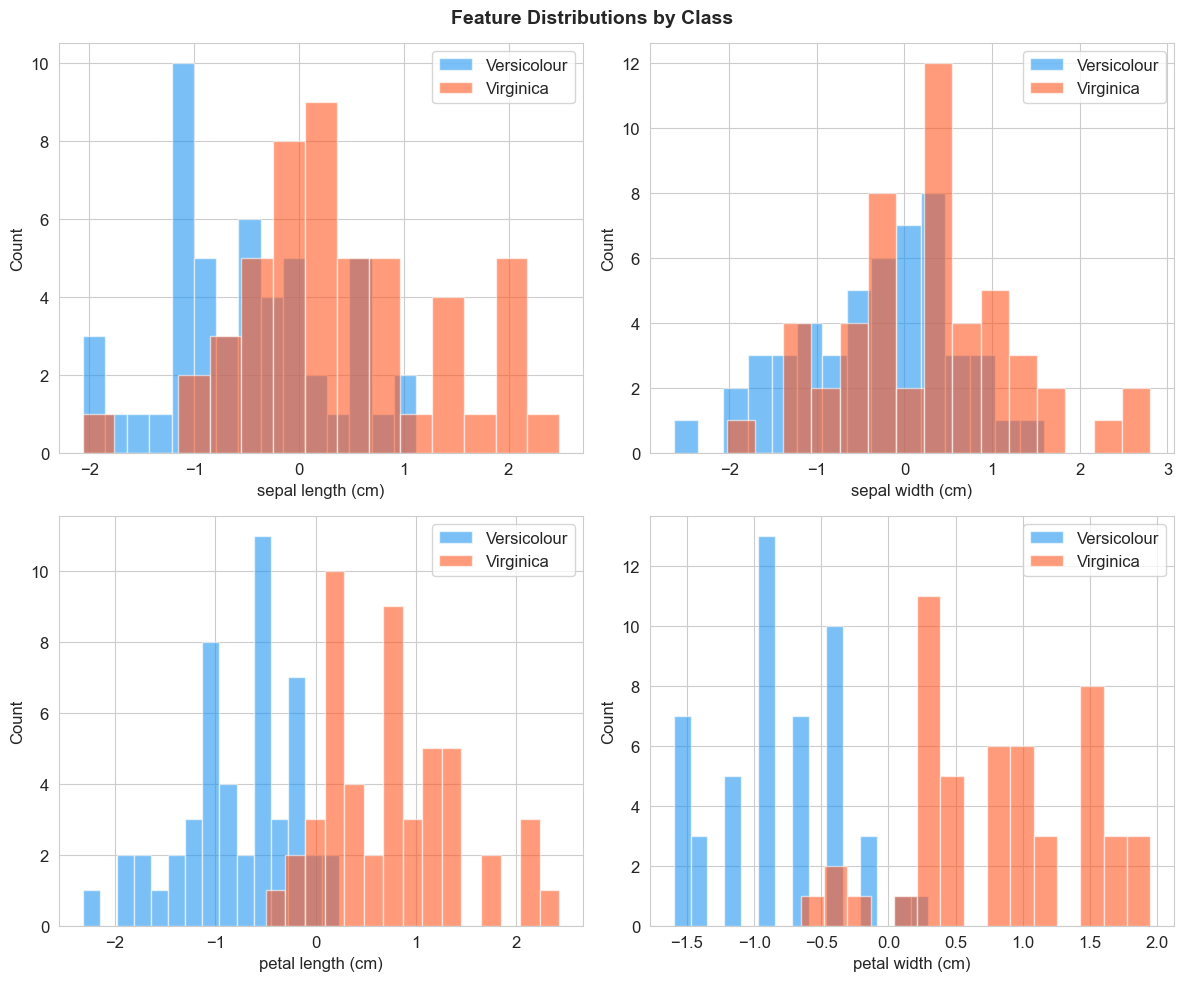

Saved: results/dataset_feature_distributions.png


In [6]:
# Pairplot of features
df = pd.DataFrame(X_scaled, columns=feature_names)
df['class'] = np.where(y == -1, 'Versicolour', 'Virginica')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')

for idx, feat in enumerate(feature_names):
    ax = axes[idx // 2, idx % 2]
    for cls, color in zip(['Versicolour', 'Virginica'], ['#2196F3', '#FF5722']):
        mask = df['class'] == cls
        ax.hist(df.loc[mask, feat], bins=15, alpha=0.6, label=cls, color=color, edgecolor='white')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('results/dataset_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/dataset_feature_distributions.png')

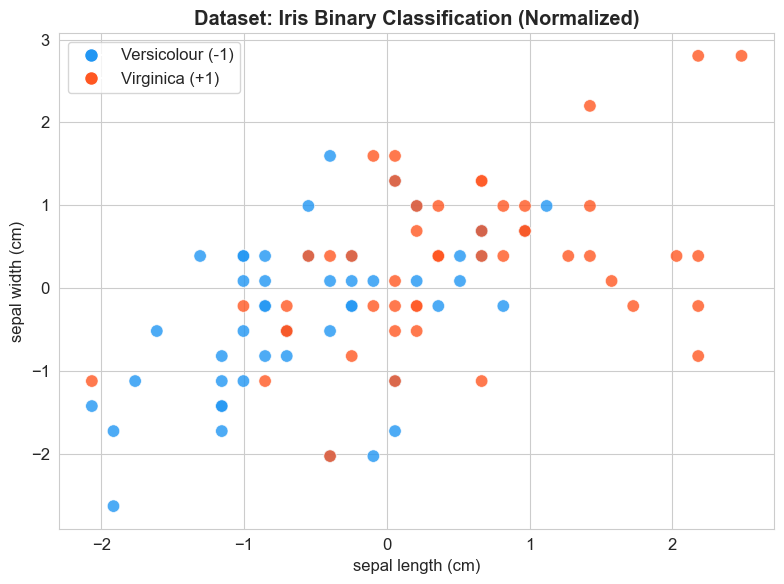

Saved: results/dataset_scatter.png


In [7]:
# 2D scatter plot using first two principal features
fig, ax = plt.subplots(figsize=(8, 6))

scatter_colors = np.where(y == -1, '#2196F3', '#FF5722')
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=scatter_colors, 
                     edgecolors='white', s=80, alpha=0.8, linewidth=0.5)

# Create legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=10, label='Versicolour (-1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF5722', markersize=10, label='Virginica (+1)')
]
ax.legend(handles=legend_elements, loc='upper left')

ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_title('Dataset: Iris Binary Classification (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig('results/dataset_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/dataset_scatter.png')

## 5. Save Preprocessed Data

Save the preprocessed data for use in subsequent notebooks.

In [8]:
# Save preprocessed data
np.savez('data/preprocessed_iris.npz',
         X_train=X_train, X_test=X_test,
         y_train=y_train, y_test=y_test,
         feature_names=feature_names)

print('Preprocessed data saved to data/preprocessed_iris.npz')
print(f'\nDataset Summary:')
print(f'  Total samples: {X.shape[0]}')
print(f'  Features: {X.shape[1]}')
print(f'  Training: {X_train.shape[0]}')
print(f'  Testing: {X_test.shape[0]}')
print(f'  Normalization: StandardScaler (zero mean, unit variance)')
print(f'  Random seed: 42')

Preprocessed data saved to data/preprocessed_iris.npz

Dataset Summary:
  Total samples: 100
  Features: 4
  Training: 80
  Testing: 20
  Normalization: StandardScaler (zero mean, unit variance)
  Random seed: 42
